In [42]:
import imageio
import matplotlib.pyplot as plt
import numpy as np

C:\Users\anapa\AppData\Local\Temp\ipykernel_16920\1149111110.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image_jeorge = imageio.imread(image_path)


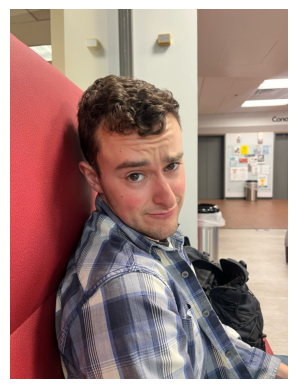

In [34]:

# Leer la imagen desde la carpeta Images
image_path = 'Images/Jeorge.jpg'
image_jeorge = imageio.imread(image_path) 


# Mostrar la imagen cargada
plt.imshow(image_jeorge )
plt.axis('off')  # Ocultar los ejes
plt.show()

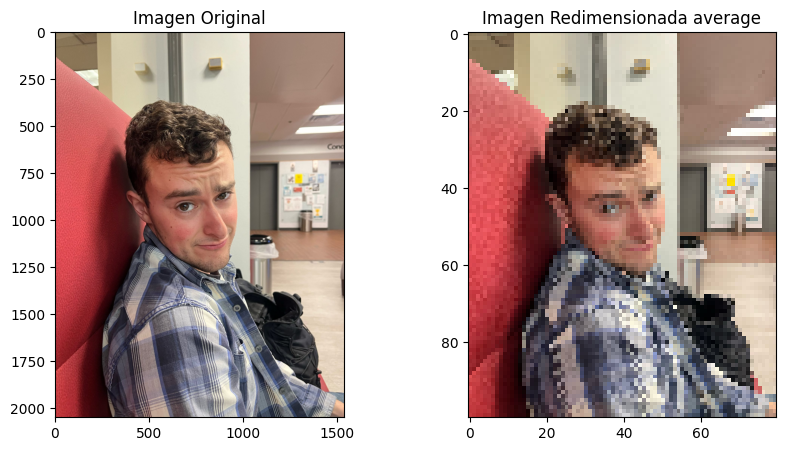

In [46]:


def resize_image(image, new_size):
    x1, y1, _ = image.shape  # Dimensiones originales
    x2, y2 = new_size        # Nuevas dimensiones
    resized_image = np.zeros((x2, y2, 3), dtype=np.uint8)
    
    # Factor de escala
    scale_x = x1 / x2
    scale_y = y1 / y2
    
    for i in range(x2):
        for j in range(y2):
            # Coordenadas en la imagen original
            x = int(i * scale_x)
            y = int(j * scale_y)
            
            # Definir el rango de vecinos considerando los bordes
            x_start = max(0, x - 1)
            x_end = min(x1, x + 2)
            y_start = max(0, y - 1)
            y_end = min(y1, y + 2)
            
            # Calcular el promedio de los píxeles vecinos en cada canal
            for c in range(3):
                neighborhood = image[x_start:x_end, y_start:y_end, c]
                resized_image[i, j, c] = int(np.mean(neighborhood))
    
    return resized_image


# Cargar imagen de prueba
#original_image = np.random.randint(0, 256, (200, 200, 3), dtype=np.uint8)
new_size = (100, 80)  # Nueva resolución

resized_image = resize_image(image_jeorge , new_size)
# Mostrar imagen original y redimensionada
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_jeorge )
ax[0].set_title("Imagen Original")
ax[1].imshow(resized_image)
ax[1].set_title("Imagen Redimensionada average")
plt.show()


In [59]:
image_jeorge

array([[[137, 120,  92],
        [139, 122,  94],
        [142, 125,  97],
        ...,
        [169, 137, 122],
        [167, 135, 120],
        [164, 132, 117]],

       [[137, 120,  92],
        [138, 121,  93],
        [141, 124,  96],
        ...,
        [171, 139, 124],
        [169, 137, 122],
        [167, 135, 120]],

       [[140, 123,  95],
        [141, 124,  96],
        [142, 125,  97],
        ...,
        [172, 140, 125],
        [171, 139, 124],
        [169, 137, 122]],

       ...,

       [[191,  56,  60],
        [192,  57,  61],
        [192,  57,  61],
        ...,
        [169, 127, 113],
        [168, 126, 112],
        [167, 125, 111]],

       [[189,  54,  58],
        [191,  56,  60],
        [192,  57,  61],
        ...,
        [168, 126, 112],
        [167, 125, 111],
        [165, 123, 109]],

       [[185,  50,  54],
        [188,  53,  57],
        [190,  55,  59],
        ...,
        [170, 128, 114],
        [169, 127, 113],
        [168, 126, 112]]

In [47]:
def calculate_average_vector(image):
    """
    Calcula el promedio de cada canal (R, G, B) de una imagen.

    Args:
        image (numpy.ndarray): Array de tamaño (x, y, 3).

    Returns:
        numpy.ndarray: Vector de 3 componentes con los promedios de los canales.
    """
    return np.mean(image, axis=(0, 1))

# Ejemplo de uso
average_vector = calculate_average_vector(image_jeorge)
print("Vector promedio (R, G, B):", average_vector)

Vector promedio (R, G, B): [150.24800809 118.20696576 112.10399818]


In [ ]:
import os
from PIL import Image

def load_images_and_vectors(folder_path):
    """
    Carga las imágenes de una carpeta y calcula sus vectores promedio.

    Args:
        folder_path (str): Ruta de la carpeta que contiene las imágenes.

    Returns:
        list: Lista de tuplas (imagen, vector_promedio).
    """
    images_and_vectors = []
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, filename)
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img)
            avg_vector = calculate_average_vector(img_array)
            images_and_vectors.append((img, avg_vector))
    return images_and_vectors

def find_closest_image(target_vector, images_and_vectors):
    """
    Encuentra la imagen más cercana al vector objetivo.

    Args:
        target_vector (numpy.ndarray): Vector objetivo.
        images_and_vectors (list): Lista de tuplas (imagen, vector_promedio).

    Returns:
        PIL.Image.Image: Imagen más cercana.
    """
    min_distance = float('inf')
    closest_image = None
    for img, avg_vector in images_and_vectors:
        distance = np.linalg.norm(target_vector - avg_vector)
        if distance < min_distance:
            min_distance = distance
            closest_image = img
    return closest_image

def create_mosaic(image, images_and_vectors, mosaic_size):
    n=0
    m=0
    """
    Crea un mosaico basado en la imagen original.

    Args:
        image (numpy.ndarray): Imagen original.
        images_and_vectors (list): Lista de tuplas (imagen, vector_promedio).
        mosaic_size (tuple): Tamaño del mosaico (filas, columnas).

    Returns:
        PIL.Image.Image: Imagen mosaico.
    """
    x2, y2 = mosaic_size
    cell_width = image.shape[1] // y2
    cell_height = image.shape[0] // x2
    mosaic = Image.new('RGB', (cell_width * y2, cell_height * x2))

    for i in range(x2):
        for j in range(y2):
            # Extraer la celda de la imagen original
            cell = image[i * cell_height:(i + 1) * cell_height, j * cell_width:(j + 1) * cell_width]
            cell_avg_vector = calculate_average_vector(cell)

            # Encontrar la imagen más cercana
            #print(cell_avg_vector,n,m)
            closest_image = find_closest_image(cell_avg_vector, images_and_vectors)

            # Redimensionar la imagen más cercana al tamaño de la celda
            closest_image_resized = closest_image.resize((cell_width, cell_height))

            # Pegar la imagen en el mosaico
            mosaic.paste(closest_image_resized, (j * cell_width, i * cell_height))
            m += 1
        n += 1

    return mosaic



In [ ]:
# Cargar las imágenes y sus vectores promedio
images_and_vectors = load_images_and_vectors('Images_set')


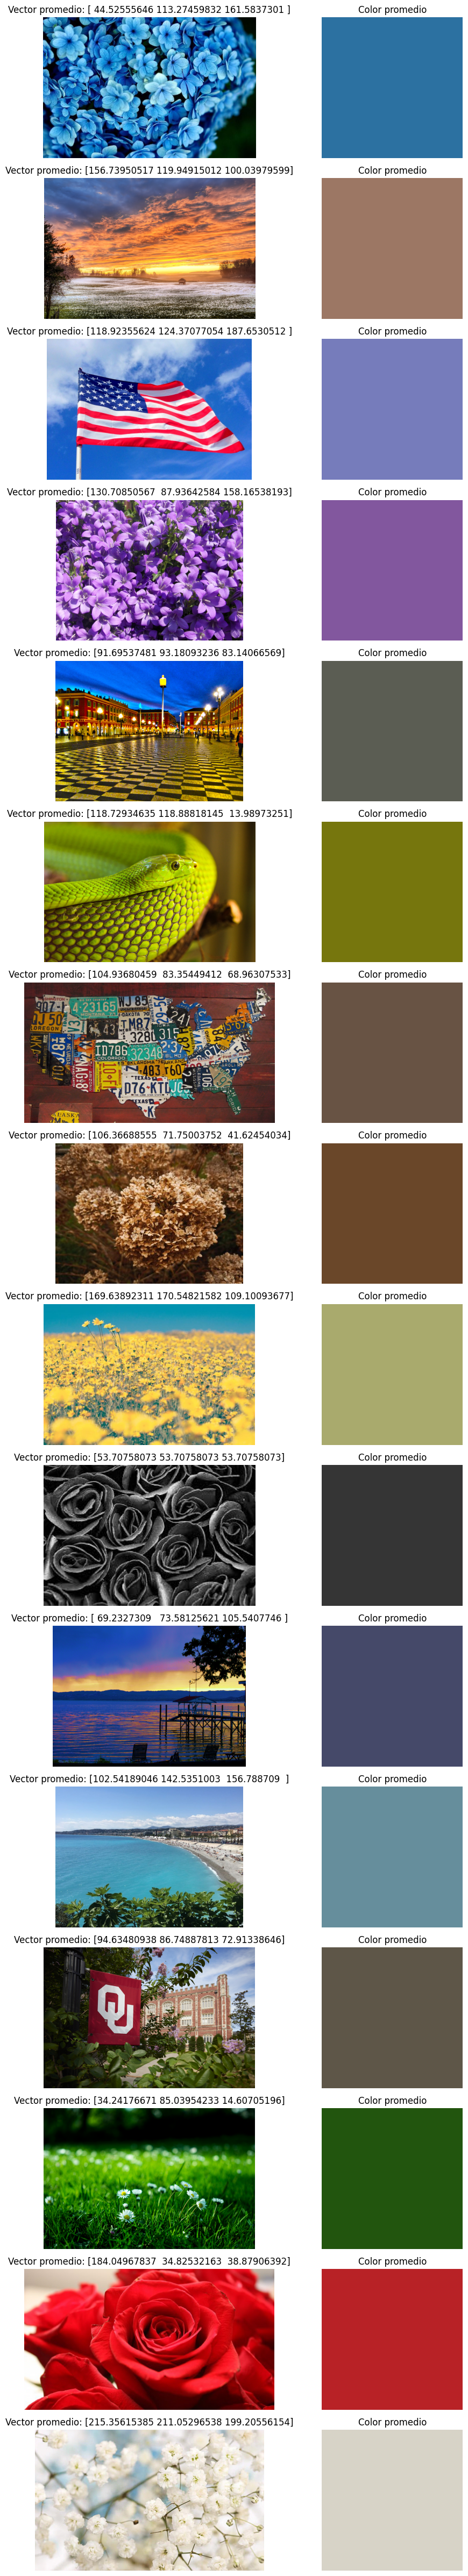

In [58]:
# Mostrar todas las imágenes, sus vectores promedio y un cuadrado con el color promedio
fig, axes = plt.subplots(len(images_and_vectors), 2, figsize=(10, len(images_and_vectors) * 3))

for i, (img, vector) in enumerate(images_and_vectors):
    # Mostrar la imagen
    axes[i, 0].imshow(img)
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"Vector promedio: {vector}")

    # Crear un cuadrado con el color promedio
    color_square = np.ones((50, 50, 3), dtype=np.uint8) * vector.astype(np.uint8)
    axes[i, 1].imshow(color_square / 255)  # Normalizar a rango [0, 1] para matplotlib
    axes[i, 1].axis('off')
    axes[i, 1].set_title("Color promedio")

plt.tight_layout()
plt.show()

In [ ]:

# Crear el mosaico
mosaic_image = create_mosaic(image_jeorge, images_and_vectors, (100, 100))

# Mostrar el mosaico
plt.imshow(mosaic_image)
plt.axis('off')
plt.show()

[144.59333333 127.19333333  98.79333333] 0 0
[146.59666667 129.19666667  99.30333333] 0 1
[147.39       129.99       101.37666667] 0 2
[149.1  130.42 100.74] 0 3
[149.24 130.32 101.92] 0 4
[142.71333333 126.40333333  97.95      ] 0 5
[125.94       109.30333333  85.87333333] 0 6
[130.29333333 113.89333333  87.99666667] 0 7
[134.26333333 116.49666667  90.83      ] 0 8
[131.40666667 113.64333333  88.04333333] 0 9
[126.49333333 109.03666667  83.18666667] 0 10
[123.25333333 103.66333333  78.33      ] 0 11
[121.33333333 101.29        76.29333333] 0 12
[122.39 102.51  77.25] 0 13
[129.05666667 109.44333333  81.75      ] 0 14
[175.37666667 157.37666667 119.35      ] 0 15
[174.39666667 156.39666667 118.39666667] 0 16
[175.01666667 157.01666667 119.01666667] 0 17
[174.82 156.82 118.82] 0 18
[180.02666667 164.27333333 128.6       ] 0 19
[215.62666667 206.49       175.57      ] 0 20
[215.56 206.56 175.56] 0 21
[215.65333333 208.45333333 176.85333333] 0 22
[215.44       207.84       176.37333333] 0